<a href="https://colab.research.google.com/github/manashvishaw-cmd/mnsit--classification/blob/main/mnsitclassificationfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: []


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Image shape      : {X_train.shape[1:]}")
print(f"Classes          : {np.unique(y_train)}")


Training samples : 60000
Testing samples  : 10000
Image shape      : (28, 28)
Classes          : [0 1 2 3 4 5 6 7 8 9]


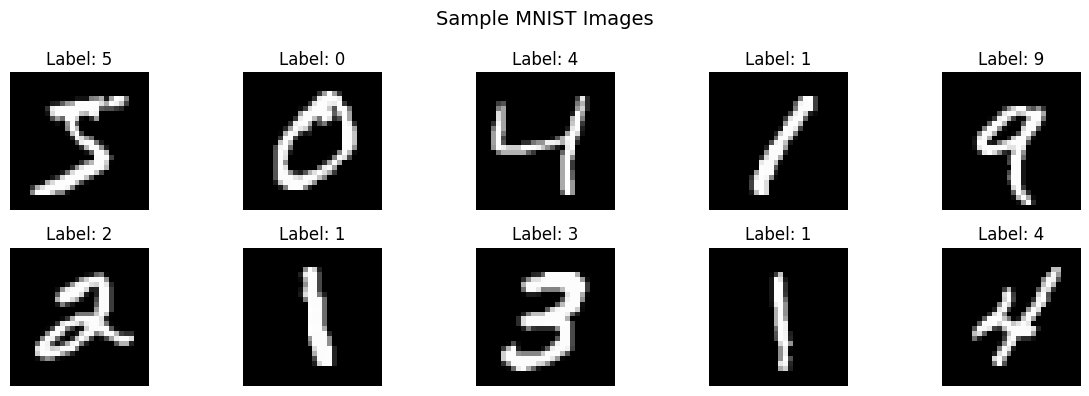

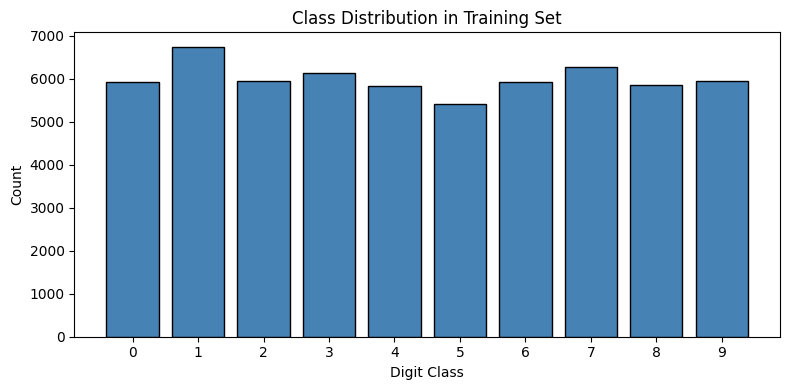

In [ ]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(*np.unique(y_train, return_counts=True), color='steelblue', edgecolor='black')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.title('Class Distribution in Training Set')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat  = X_test.reshape(-1,  28 * 28)

y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print(f"Flattened train shape: {X_train_flat.shape}")
print(f"Flattened test shape : {X_test_flat.shape}")
print(f"Label before one-hot : {y_train[0]}")
print(f"Label after  one-hot : {y_train_ohe[0]}")

Flattened train shape: (60000, 784)
Flattened test shape : (10000, 784)
Label before one-hot : 5
Label after  one-hot : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_flat, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9127 - loss: 0.2890 - val_accuracy: 0.9712 - val_loss: 0.0961
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9651 - loss: 0.1150 - val_accuracy: 0.9720 - val_loss: 0.0958
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9737 - loss: 0.0826 - val_accuracy: 0.9778 - val_loss: 0.0769
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9797 - loss: 0.0631 - val_accuracy: 0.9775 - val_loss: 0.0731
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9829 - loss: 0.0529 - val_accuracy: 0.9825 - val_loss: 0.0603
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9848 - loss: 0.0470 - val_accuracy: 0.9805 - val_loss: 0.0717
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9867 - loss: 0.0409 - val_accuracy: 0.9823 - val_loss: 0.0672
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9877 - loss: 0.0367 - val_acc

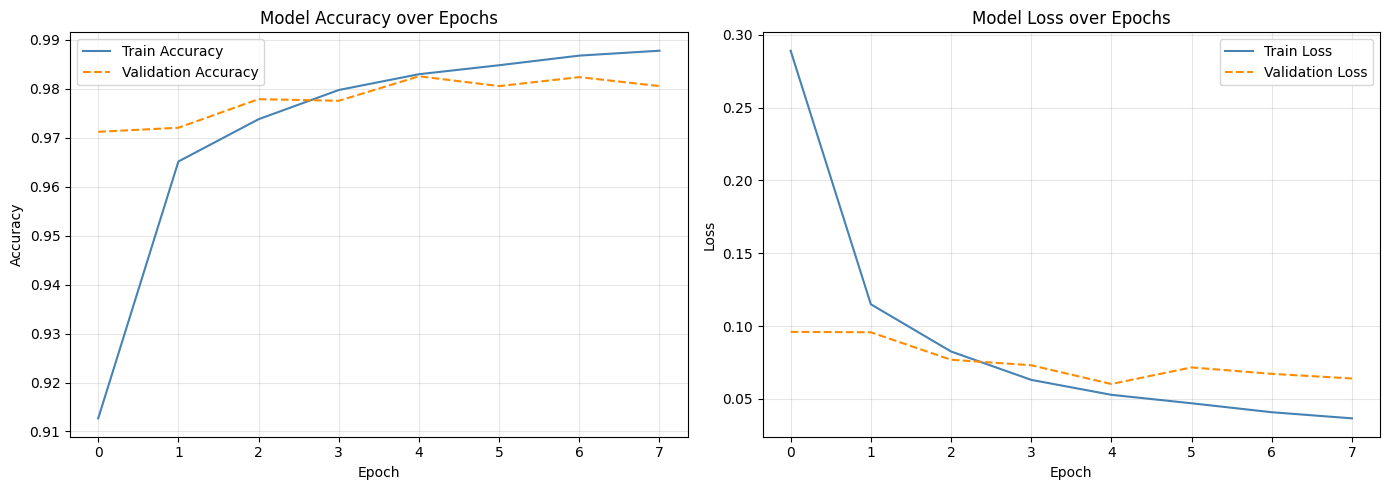

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linestyle='--')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linestyle='--')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_ohe, verbose=0)

print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 40)



  Test Loss     : 0.0664
  Test Accuracy : 97.96%


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


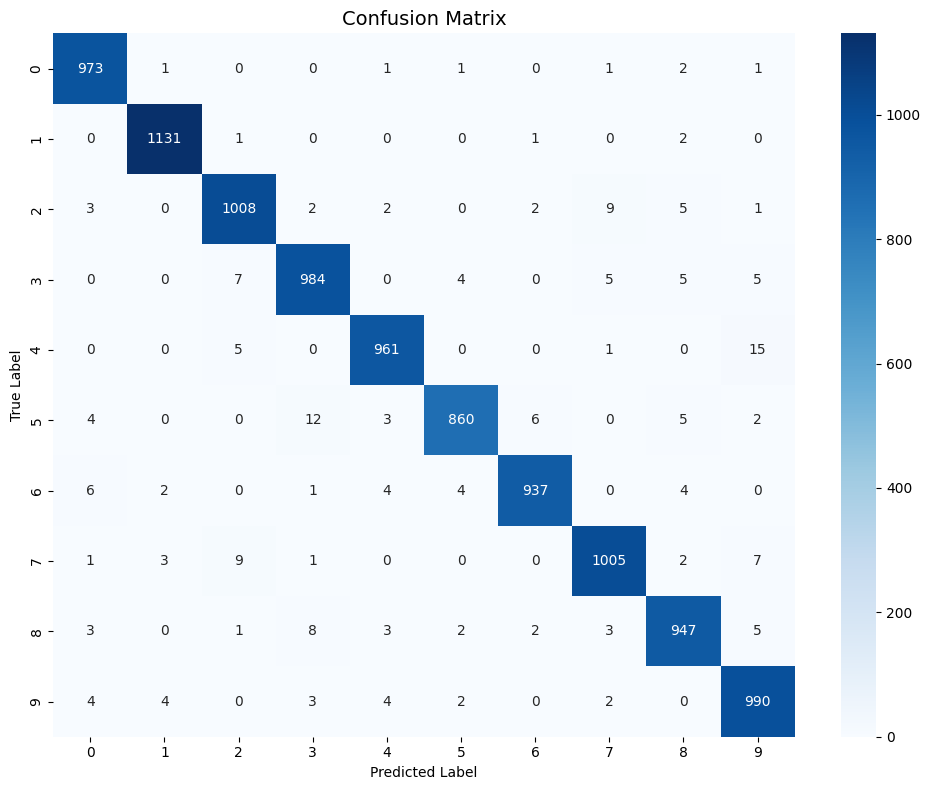


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.96      0.97       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
y_pred_probs = model.predict(X_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))



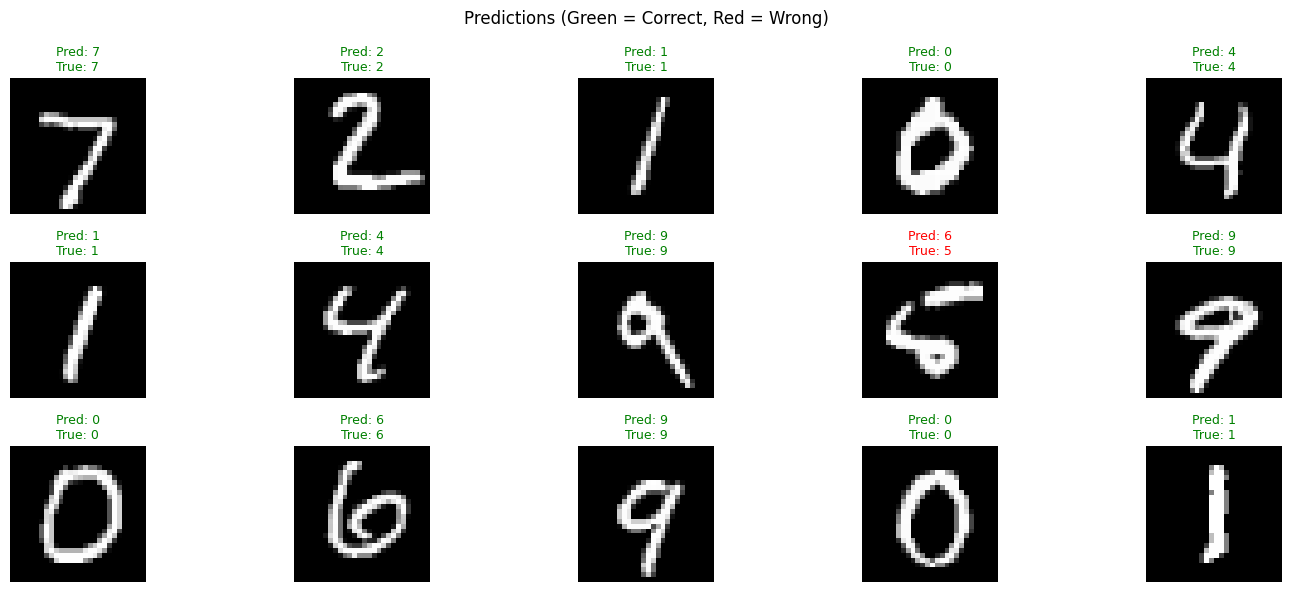

In [ ]:
plt.figure(figsize=(15, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    pred = y_pred[i]
    true = y_true[i]
    color = 'green' if pred == true else 'red'
    plt.title(f'Pred: {pred}\nTrue: {true}', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('Predictions (Green = Correct, Red = Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

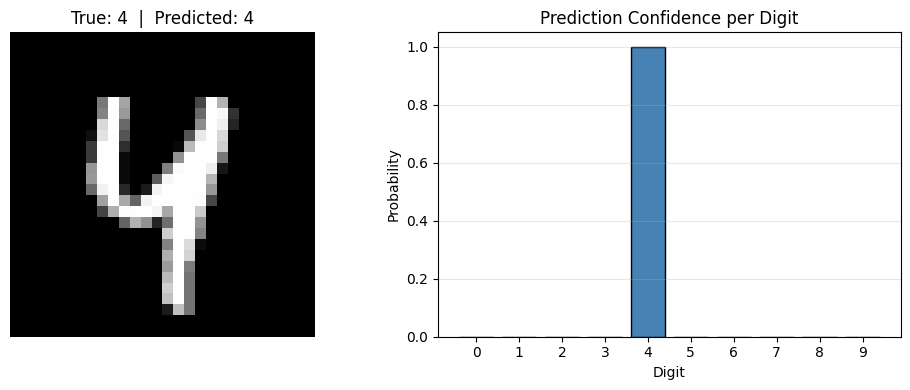

Predicted Digit : 4
Confidence      : 100.00%


In [ ]:
idx = 42

sample_image = X_test[idx]
sample_flat = sample_image.reshape(1, 784)

prediction_probs = model.predict(sample_flat, verbose=0)[0]
predicted_digit = np.argmax(prediction_probs)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title(f'True: {y_test[idx]}  |  Predicted: {predicted_digit}', fontsize=12)
axes[0].axis('off')

axes[1].bar(range(10), prediction_probs, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(10))
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Probability')
axes[1].set_title('Prediction Confidence per Digit')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Predicted Digit : {predicted_digit}")
print(f"Confidence      : {prediction_probs[predicted_digit]*100:.2f}%")


In [ ]:
model.save('mnist_digit_classifier.keras')
print("Model saved as 'mnist_digit_classifier.keras'")


Model saved as 'mnist_digit_classifier.keras'


In [ ]:
from google.colab import files
files.download('mnist_digit_classifier.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()


Saving images.jpg to images.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


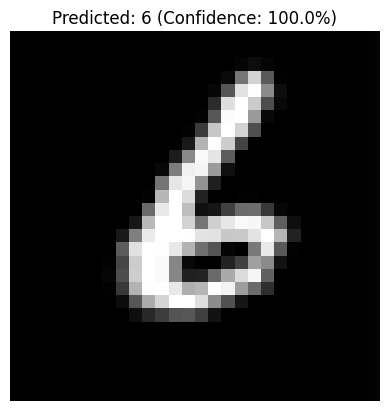

In [ ]:
for filename in uploaded.keys():
     img = Image.open(filename).convert('L')
     img = img.resize((28, 28))
     img_array = np.array(img).astype('float32') / 255.0
     img_array = 1 - img_array
     img_flat = img_array.reshape(1, 784)

     pred_probs = model.predict(img_flat)[0]
     pred_digit = np.argmax(pred_probs)

     plt.imshow(img_array, cmap='gray')
     plt.title(f'Predicted: {pred_digit} (Confidence: {pred_probs[pred_digit]*100:.1f}%)')
     plt.axis('off')
     plt.show()